In [2]:
from __future__ import annotations

from collections import defaultdict
from hashlib import sha256
from pathlib import Path
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.io import loadmat

sns.set_theme(style="whitegrid")
PROJECT_ROOT = next((parent for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (parent / "PROJECT_SPEC.md").exists()), Path.cwd().resolve())
RAW_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "reports" / "eda"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
MAT_FILES = sorted(path for path in RAW_DIR.rglob("*.mat") if path.name.lower() != "cvind.mat")
EXPECTED_FIELDS = {"label", "PID", "image", "tumorBorder", "tumorMask"}
RAW_LABEL_TO_NAME = {1: "meningioma", 2: "glioma", 3: "pituitary tumor"}
RAW_LABEL_TO_CLASS_INDEX = {1: 1, 2: 0, 3: 2}
CLASS_INDEX_TO_NAME = {0: "glioma", 1: "meningioma", 2: "pituitary tumor"}
print(f"Project root: {PROJECT_ROOT}")
print(f"MAT files found: {len(MAT_FILES):,}")
assert MAT_FILES, f"Cannot find .mat file in {RAW_DIR}"


def _scalar(value):
    array = np.asarray(value).squeeze()
    return array.item() if array.size == 1 else array


def load_case(path: Path) -> dict:
    try:
        mat = loadmat(path, squeeze_me=True, struct_as_record=False)
        if "cjdata" not in mat:
            raise KeyError("missing cjdata")
        cjdata = mat["cjdata"]
        fields = {name: getattr(cjdata, name) for name in EXPECTED_FIELDS if hasattr(cjdata, name)}
    except NotImplementedError:
        with h5py.File(path, "r") as mat:
            if "cjdata" not in mat:
                raise KeyError("missing cjdata")
            group = mat["cjdata"]
            fields = {name: np.asarray(group[name]) for name in EXPECTED_FIELDS if name in group}
    missing = EXPECTED_FIELDS - fields.keys()
    if missing:
        raise KeyError(f"missing fields: {sorted(missing)}")
    return fields


Project root: C:\Users\ADMIN\Documents\Ky7\DL\multi-class-brain-tumor-classification\new_project
MAT files found: 3,064


In [3]:
# Kiểm tra schema của một file mẫu trước khi quét toàn bộ dữ liệu.
first_case = load_case(MAT_FILES[0])
print("First file:", MAT_FILES[0].relative_to(RAW_DIR))
print("Fields:", sorted(first_case))
print("Image shape:", np.asarray(first_case["image"]).shape)
print("Mask shape:", np.asarray(first_case["tumorMask"]).shape)
print("Raw label:", int(_scalar(first_case["label"])))
print("Patient ID:", _scalar(first_case["PID"]))


First file: brainTumorDataPublic_1-766\1.mat
Fields: ['PID', 'image', 'label', 'tumorBorder', 'tumorMask']
Image shape: (512, 512)
Mask shape: (512, 512)
Raw label: 1
Patient ID: [49 48 48 51 54 48]


- PID: Mã bệnh nhân, được lưu thành vector mã ASCII.  
[49 48 48 51 54 48] -> "100360"

- image: Ảnh MRI grayscale kích thước 512 x 512.

- label: Loại tumor:  
    1 -> meningioma  
    2 -> glioma  
    3 -> pituitary tumor  

- tumorBorder: Vector các cặp tọa độ tạo đường viền tumor.

- tumorMask: Ma trận 512 x 512 đánh dấu vùng tumor:  
    0 -> nền  
    >0 -> vùng tumor  

In [4]:
# Quét toàn bộ file và tạo inventory.
records, errors, image_hashes = [], [], defaultdict(list)
for path in MAT_FILES:
    try:
        case = load_case(path)
        image, mask = np.asarray(case["image"]), np.asarray(case["tumorMask"])
        raw_label = int(_scalar(case["label"]))
        patient_id = str(_scalar(case["PID"]))
        image_hash = sha256(np.ascontiguousarray(image).tobytes()).hexdigest()
        image_hashes[image_hash].append(path.name)
        records.append({
            "file": str(path.relative_to(RAW_DIR)), "filename": path.name,
            "raw_label": raw_label, "raw_class": RAW_LABEL_TO_NAME.get(raw_label, "unknown"),
            "class_index": RAW_LABEL_TO_CLASS_INDEX.get(raw_label, -1),
            "class_name": CLASS_INDEX_TO_NAME.get(RAW_LABEL_TO_CLASS_INDEX.get(raw_label, -1), "unknown"),
            "patient_id": patient_id, "image_height": image.shape[0], "image_width": image.shape[1],
            "image_ndim": image.ndim, "image_dtype": str(image.dtype),
            "pixel_min": float(np.nanmin(image)), "pixel_max": float(np.nanmax(image)),
            "pixel_mean": float(np.nanmean(image)), "pixel_std": float(np.nanstd(image)),
            "finite_pixels": bool(np.isfinite(image).all()),
            "mask_foreground_ratio": float(np.mean(mask > 0)), "image_sha256": image_hash,
        })
    except Exception as exc:
        errors.append({"file": str(path.relative_to(RAW_DIR)), "error": repr(exc)})
df = pd.DataFrame(records)
errors_df = pd.DataFrame(errors)
print(f"Valid files: {len(df):,}")
print(f"Invalid files: {len(errors_df):,}")
display(df.head())


Valid files: 3,064
Invalid files: 0


,file,filename,raw_label,raw_class,class_index,class_name,patient_id,image_height,image_width,image_ndim,image_dtype,pixel_min,pixel_max,pixel_mean,pixel_std,finite_pixels,mask_foreground_ratio,image_sha256
0,brainTumorDataPublic_1-766\1.mat,1.mat,1,meningioma,1,meningioma,[49 48 48 51 54 48],512,512,2,int16,0.0,3366.0,441.478424,617.097037,True,0.017429,3395e81b1982f18bf48ce97b3f999ca6229c28585ea6b8...
1,brainTumorDataPublic_1-766\10.mat,10.mat,1,meningioma,1,meningioma,[49 48 49 48 49 54],512,512,2,int16,0.0,2857.0,283.765354,416.816618,True,0.014141,1c423b7061d50a95db1066aa88d7b773299a47551f3659...
2,brainTumorDataPublic_1-766\100.mat,100.mat,1,meningioma,1,meningioma,[49 48 55 52 57 52],512,512,2,int16,0.0,5047.0,679.562420,883.758569,True,0.009319,e937d742c8eeb626ab0683cb16834b6d915e138d6ece4a...
3,brainTumorDataPublic_1-766\101.mat,101.mat,1,meningioma,1,meningioma,[49 48 55 52 57 52],512,512,2,int16,0.0,4814.0,700.528187,891.096774,True,0.012489,0a4d4cfa82a40164bfb47b86fa4d84dff51b9267586ee9...
4,brainTumorDataPublic_1-766\102.mat,102.mat,1,meningioma,1,meningioma,[49 48 55 52 57 52],512,512,2,int16,0.0,5190.0,725.603683,882.696611,True,0.018131,8b1210420d0268e29ebcbc568ded73879ddcb0cf0ea4c5...


`finite_pixels = True`: Tất cả pixel trong ảnh đều là số hợp lệ, không có NaN và không có ±∞.

In [5]:
# Output 1: chất lượng dữ liệu, kích thước ảnh và duplicate.
assert not df.empty
assert set(df["raw_label"]).issubset(RAW_LABEL_TO_NAME)
assert df["finite_pixels"].all()
summary = pd.DataFrame({"value": [len(df), df["patient_id"].nunique(), len(df["image_sha256"].unique()), len(errors_df)]}, index=["valid_images", "unique_patients", "unique_image_hashes", "invalid_files"])
patient_class_counts = df.groupby("patient_id")["class_name"].nunique()
duplicate_groups = df.groupby("image_sha256", as_index=False).agg(duplicate_count=("filename", "size"), files=("filename", list))
duplicates = duplicate_groups[duplicate_groups["duplicate_count"] > 1]
display(summary)
print(f"Patients in multiple classes: {(patient_class_counts > 1).sum():,}")
print(f"Exact duplicate image groups: {len(duplicates):,}")
print("Image shapes:")
display(df.groupby(["image_height", "image_width"], as_index=False).size().sort_values("size", ascending=False).head(20))


,value
valid_images,3064
unique_patients,233
unique_image_hashes,3064
invalid_files,0


Patients in multiple classes: 0
Exact duplicate image groups: 0
Image shapes:


,image_height,image_width,size
1,512,512,3049
0,256,256,15


,class_index,class_name,images,percentage
0,0,glioma,1426,46.54047
1,1,meningioma,708,23.10705
2,2,pituitary tumor,930,30.35248


,count,mean,std,min,25%,50%,75%,max
pixel_min,3064.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
pixel_max,3064.0,3390.139034,2146.146428,238.000000,1999.750000,2950.000000,4476.500000,12728.000000
pixel_mean,3064.0,467.385598,215.988595,44.886505,309.202133,479.450779,604.205674,1238.030445
pixel_std,3064.0,523.479563,291.206772,34.894822,334.603455,492.536219,698.195425,1644.918765
mask_foreground_ratio,3064.0,0.016901,0.013790,0.000973,0.006537,0.012856,0.023205,0.097126


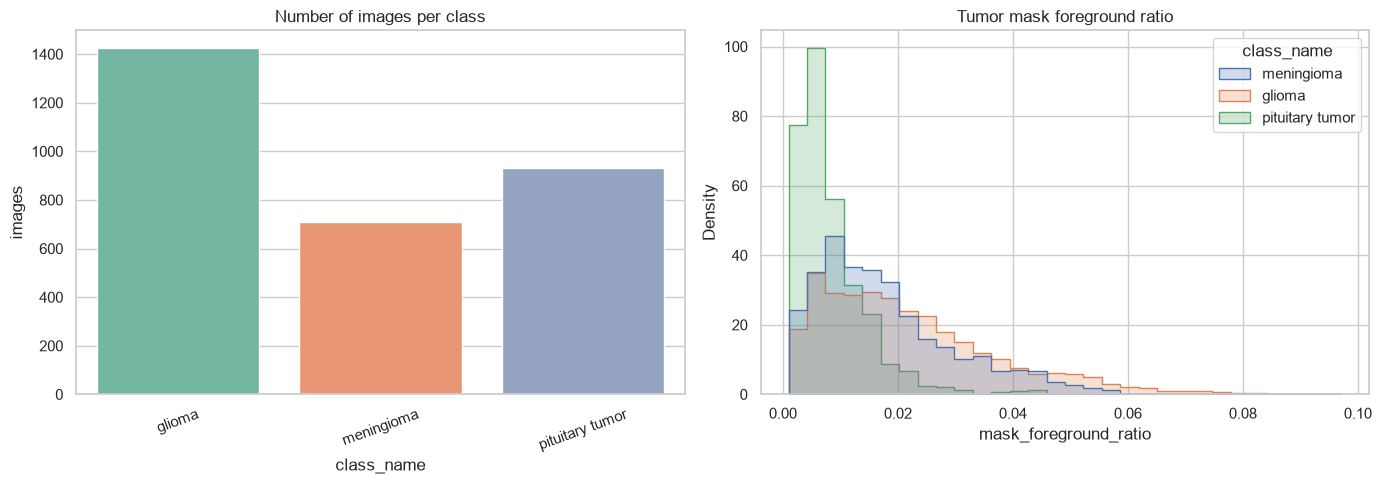

In [6]:
# Output 2: phân bố class và thống kê pixel/mask.
class_counts = (df.groupby(["class_index", "class_name"], as_index=False).size().rename(columns={"size": "images"}).sort_values("class_index"))
class_counts["percentage"] = class_counts["images"] / len(df) * 100
display(class_counts)
display(df[["pixel_min", "pixel_max", "pixel_mean", "pixel_std", "mask_foreground_ratio"]].describe().T)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=class_counts, x="class_name", y="images", hue="class_name", legend=False, palette="Set2", ax=axes[0])
axes[0].set_title("Number of images per class")
axes[0].tick_params(axis="x", rotation=20)
sns.histplot(data=df, x="mask_foreground_ratio", hue="class_name", bins=30, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Tumor mask foreground ratio")
plt.tight_layout()
plt.show()


Dataset có phân bố class không hoàn toàn cân bằng: glioma chiếm 46.54%, meningioma 23.11% và pituitary tumor 30.35%. Tỷ lệ giữa class lớn nhất và nhỏ nhất xấp xỉ 2:1, cho thấy imbalance ở mức nhẹ đến vừa, chưa đủ nghiêm trọng để loại bỏ dữ liệu. Tuy nhiên, việc đánh giá cần sử dụng macro precision, macro recall, macro F1-score và confusion matrix thay vì chỉ dựa vào accuracy.

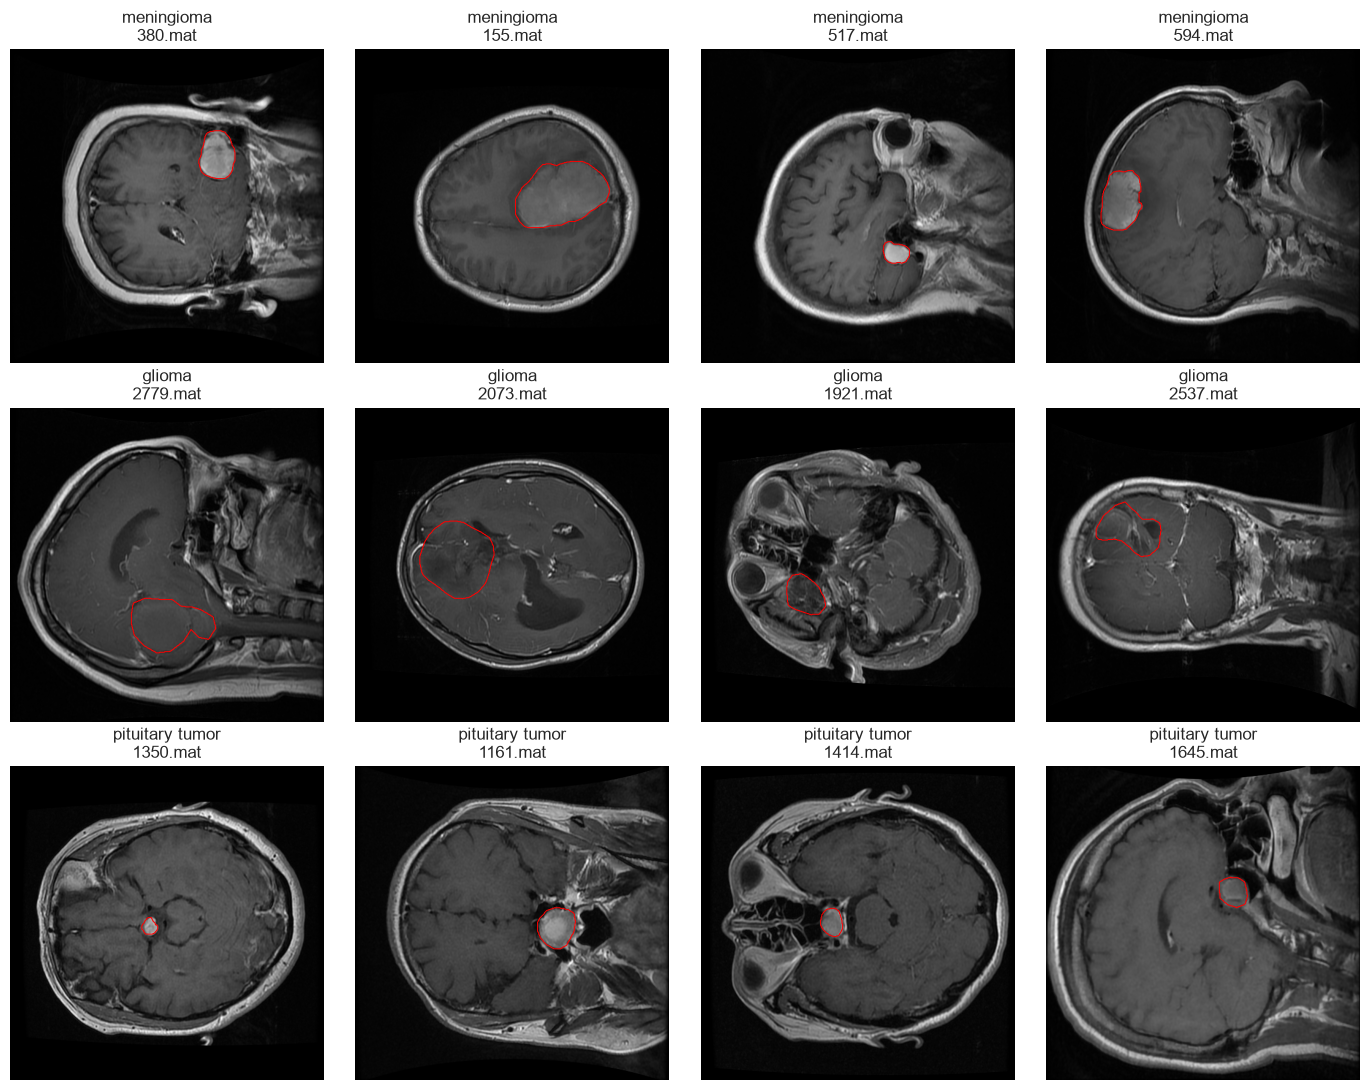

In [7]:
# Output 3: ảnh MRI ngẫu nhiên, overlay tumor mask.
rng = np.random.default_rng(42)
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for row, (raw_label, class_name) in enumerate(RAW_LABEL_TO_NAME.items()):
    class_rows = df[df["raw_label"] == raw_label]
    selected = class_rows.iloc[rng.choice(len(class_rows), size=min(4, len(class_rows)), replace=False)]
    for col, (_, record) in enumerate(selected.iterrows()):
        case = load_case(RAW_DIR / record["file"])
        axes[row, col].imshow(case["image"], cmap="gray")
        axes[row, col].contour(np.asarray(case["tumorMask"]) > 0, levels=[0.5], colors="red", linewidths=0.7)
        axes[row, col].set_title(f"{class_name}\n{record['filename']}")
        axes[row, col].axis("off")
    for col in range(len(selected), 4):
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

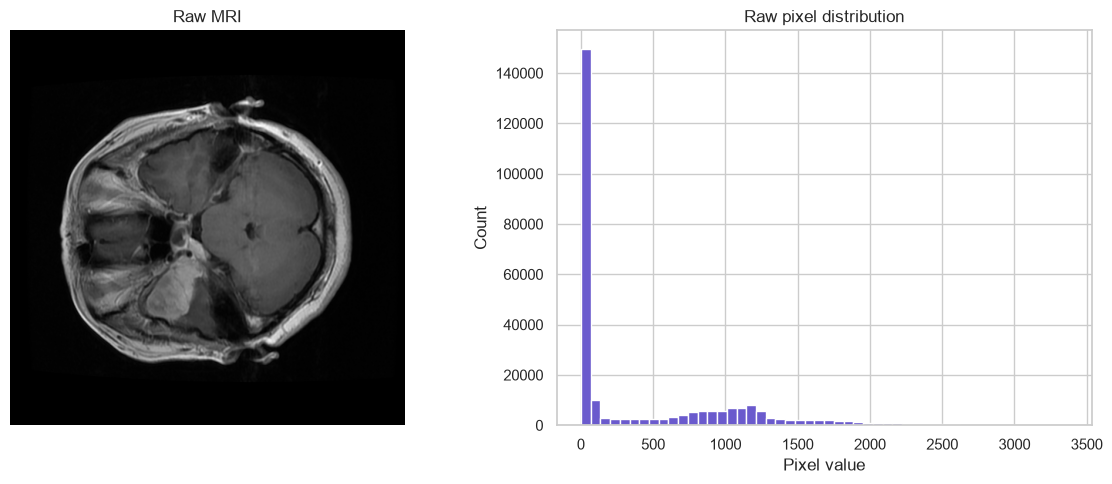

In [10]:
# Output 4: histogram pixel của một ảnh đại diện.
sample_image = np.asarray(load_case(RAW_DIR / df.iloc[0]["file"])["image"])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(sample_image, cmap="gray")
axes[0].set_title("Raw MRI")
axes[0].axis("off")
axes[1].hist(sample_image.ravel(), bins=50, color="slateblue")
axes[1].set_title("Raw pixel distribution")
axes[1].set_xlabel("Pixel value")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

In [9]:
# Lưu các bảng để preprocessing dùng lại.
df.to_csv(REPORT_DIR / "file_inventory.csv", index=False)
class_counts.to_csv(REPORT_DIR / "class_counts.csv", index=False)
summary.to_csv(REPORT_DIR / "dataset_summary.csv", header=True)
if not errors_df.empty:
    errors_df.to_csv(REPORT_DIR / "invalid_files.csv", index=False)
if not duplicates.empty:
    duplicates.to_csv(REPORT_DIR / "exact_duplicate_groups.csv", index=False)
metadata = {"raw_label_to_class_index": RAW_LABEL_TO_CLASS_INDEX, "class_index_to_name": CLASS_INDEX_TO_NAME, "num_mat_files_found": len(MAT_FILES), "num_valid_files": len(df), "num_invalid_files": len(errors_df), "num_unique_patients": int(df["patient_id"].nunique())}
(REPORT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print(f"EDA outputs saved to: {REPORT_DIR}")

EDA outputs saved to: C:\Users\ADMIN\Documents\Ky7\DL\multi-class-brain-tumor-classification\new_project\reports\eda
